In [553]:
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from tools import plot_session_with_news
from backtester import backtest

In [554]:
DATA_DIR = "../data"

bars_seen_train         = pd.read_parquet(os.path.join(DATA_DIR, "bars_seen_train.parquet"), engine="fastparquet")
bars_unseen_train       = pd.read_parquet(os.path.join(DATA_DIR, "bars_unseen_train.parquet"), engine="fastparquet")
bars_seen_public_test   = pd.read_parquet(os.path.join(DATA_DIR, "bars_seen_public_test.parquet"), engine="fastparquet")
bars_seen_private_test  = pd.read_parquet(os.path.join(DATA_DIR, "bars_seen_private_test.parquet"), engine="fastparquet")

headlines_seen_train        = pd.read_parquet(os.path.join(DATA_DIR, "headlines_seen_train.parquet"), engine="fastparquet")
headlines_unseen_train      = pd.read_parquet(os.path.join(DATA_DIR, "headlines_unseen_train.parquet"), engine="fastparquet")
headlines_seen_public_test  = pd.read_parquet(os.path.join(DATA_DIR, "headlines_seen_public_test.parquet"), engine="fastparquet")
headlines_seen_private_test = pd.read_parquet(os.path.join(DATA_DIR, "headlines_seen_private_test.parquet"), engine="fastparquet")

print("bars_seen_train:",         bars_seen_train.shape)
print("bars_unseen_train:",       bars_unseen_train.shape)
print("bars_seen_public_test:",   bars_seen_public_test.shape)
print("bars_seen_private_test:",  bars_seen_private_test.shape)
print("headlines_seen_train:",        headlines_seen_train.shape)
print("headlines_unseen_train:",      headlines_unseen_train.shape)
print("headlines_seen_public_test:",  headlines_seen_public_test.shape)
print("headlines_seen_private_test:", headlines_seen_private_test.shape)

bars_seen_train: (50000, 6)
bars_unseen_train: (50000, 6)
bars_seen_public_test: (500000, 6)
bars_seen_private_test: (500000, 6)
headlines_seen_train: (9740, 3)
headlines_unseen_train: (7631, 3)
headlines_seen_public_test: (99308, 3)
headlines_seen_private_test: (99148, 3)


In [555]:
headlines_seen_train['session'].nunique()

1000

In [556]:
sentiment = pd.read_csv("../anna/headline_stats_seen_train.csv")
sentiment.head(10)

,session,headline,bar_ix,decided_label,prob_positive,prob_negative,prob_neutral,linear_score,polarity_score,cluster
0,0,Relvos Biosciences,6,neutral,0.387032,0.013454,0.599514,0.373578,0.932811,0
1,0,Orevex Renewables,12,positive,0.948091,0.012295,0.039614,0.935795,0.974395,1
2,0,Relvos Biosciences,14,neutral,0.061307,0.040272,0.898421,0.021034,0.207074,0
3,0,Calvis Sciences,20,positive,0.945060,0.010088,0.044852,0.934971,0.978876,0
4,0,Yorvov Pharmaceuticals,22,positive,0.947761,0.012083,0.040155,0.935678,0.974823,0
5,0,Relvos Biosciences,26,negative,0.008312,0.974797,0.016890,-0.966485,-0.983090,0
6,0,Relvos Biosciences,26,positive,0.948155,0.012102,0.039743,0.936053,0.974793,0
7,0,Calvis Sciences,33,positive,0.760141,0.008625,0.231234,0.751516,0.977561,0
8,0,Yorvov Pharmaceuticals,44,negative,0.026838,0.947266,0.025896,-0.920428,-0.944897,0
9,0,Orevex Renewables,47,positive,0.950261,0.013908,0.035830,0.936353,0.971149,1


In [557]:
sentiment['prob_negative'].max()

0.9767503142356871

In [558]:
# We will check which sessions had headlines that were actually informative 
def check_headline(sentiment: pd.DataFrame, headlines_seen_train: pd.DataFrame, bars_seen_train: pd.DataFrame):
    total_bars = pd.concat([bars_seen_train, bars_unseen_train], ignore_index=True)
    correct_predictions = {i : 0 for i in headlines_seen_train['session'].unique()}
    proportion_correct = {i : 0 for i in headlines_seen_train['session'].unique()}
    for session in headlines_seen_train['session'].unique():
        session_headlines = headlines_seen_train[headlines_seen_train['session'] == session]
        if session_headlines.empty:
            continue

        sesh = sentiment[sentiment['session'] == session]
        bar_sesh = total_bars[total_bars['session'] == session]
        for idx, row in sesh.iterrows():
            bar_idx = row['bar_ix']
            #Return on this bar_ix 
            ret = np.log(bar_sesh.iloc[bar_idx + 1]['close'] / bar_sesh.iloc[bar_idx]['close'])
            
            #correct prediction
            if row['decided_label'] == 'positive' and ret > 0:
                correct_predictions[session]+=1 
            elif row['decided_label'] == 'negative' and ret < 0:
                correct_predictions[session]+=1
                
            #incorrect prediction
            elif row['decided_label'] == 'positive' and ret < 0:
                correct_predictions[session]-=1
            elif row['decided_label'] == 'negative' and ret > 0:
                correct_predictions[session]-=1

    for session in proportion_correct:
        total_predictions = len(headlines_seen_train[headlines_seen_train['session'] == session])
        if total_predictions > 0:
            proportion_correct[session] = correct_predictions[session] / total_predictions

    return proportion_correct, correct_predictions

prop_correct, correct_predictions = check_headline(sentiment, headlines_seen_train, bars_seen_train)
            

In [559]:
prop_correct_df = pd.DataFrame(list(prop_correct.items()), columns=['session', 'proportion_correct'])
prop_correct_df.sort_values(by='proportion_correct', ascending=False, inplace=True)
prop_correct_df.head(10)

,session,proportion_correct
748,748,0.857143
711,711,0.857143
860,860,0.800000
879,879,0.800000
858,858,0.750000
591,591,0.714286
224,224,0.714286
567,567,0.666667
736,736,0.666667
964,964,0.666667


In [560]:
correct_predictions[860]

8

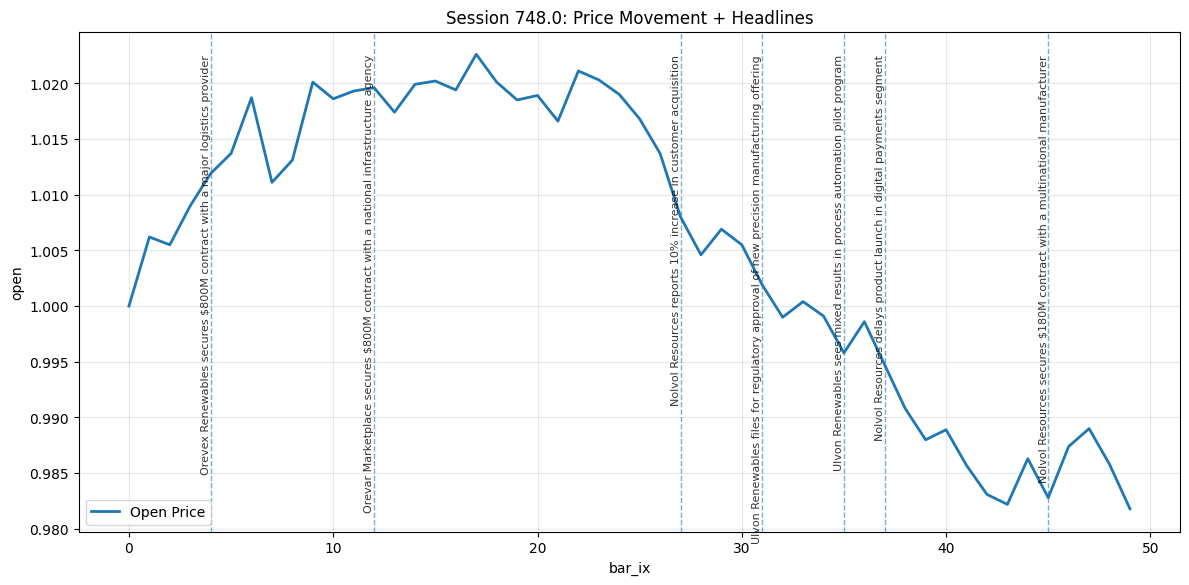

In [561]:
plot_session_with_news(
    bars_seen_train,
    headlines_seen_train,
    session_n=prop_correct_df.iloc[0]['session'],
    price_col="open",
    figsize=(12, 6),
    show_headlines=True,
)

In [562]:
sentiment_unseen = pd.read_csv("../anna/headline_stats_unseen_train.csv")
sentiment_unseen.head(10)

,session,headline,bar_ix,decided_label,prob_positive,prob_negative,prob_neutral,linear_score,polarity_score,cluster
0,0,Orevex Renewables,51,neutral,0.072570,0.017445,0.909985,0.055125,0.612391,1
1,0,Yorvov Pharmaceuticals,53,positive,0.942358,0.010091,0.047551,0.932267,0.978811,0
2,0,Relvos Biosciences,55,positive,0.943893,0.012349,0.043759,0.931544,0.974173,0
3,0,Calvis Sciences,59,neutral,0.057537,0.037620,0.904842,0.019917,0.209310,0
4,0,Calvis Sciences,62,negative,0.024791,0.948185,0.027024,-0.923394,-0.949042,0
5,0,Yorvov Pharmaceuticals,68,positive,0.956354,0.020158,0.023488,0.936196,0.958715,0
6,0,Relvos Biosciences,68,neutral,0.067851,0.016860,0.915289,0.050990,0.601933,0
7,0,Yorvov Pharmaceuticals,71,negative,0.010613,0.951251,0.038136,-0.940638,-0.977932,0
8,0,Orevex Renewables,74,neutral,0.232315,0.008153,0.759532,0.224163,0.932194,1
9,0,Calvis Sciences,82,neutral,0.090314,0.011936,0.897750,0.078379,0.766538,0


In [563]:
# Look at headlines that contain the word "breakthrough" and flag these sessions
breakthrough_headlines = headlines_seen_train[headlines_seen_train['headline'].str.contains('robust', case=False)]
breakthrough_sessions = breakthrough_headlines['session'].unique()

misses_headlines = headlines_seen_train[headlines_seen_train['headline'].str.contains('merger', case=False)]
misses_sessions = misses_headlines['session'].unique()

trade_decision_breakthrough = pd.DataFrame({
    "session": [i for i in breakthrough_sessions],
    "volume": 1,
})

trade_decision_misses = pd.DataFrame({
    "session": [i for i in misses_sessions],
    "volume":0,
})
trade_decision = pd.concat([trade_decision_breakthrough, trade_decision_misses], ignore_index=True)
# for i in range(1000):
#     if i in breakthrough_sessions:
#         trade_decision.loc[trade_decision['session'] == i, 'volume'] = 1

backtest(trade_decision)

  Sessions evaluated : 49
  Sharpe ratio       : +1.3686
  Mean PnL           : +0.001376
  Std  PnL           : 0.016089
  Win rate           : 32.65%


,session,volume,close_halfway,close_end,ret,pnl
0,105,1,1.0213,1.0133,-0.007833,-0.007833
1,106,1,0.9934,0.9330,-0.060801,-0.060801
2,144,1,1.0370,1.0342,-0.002700,-0.002700
3,170,1,1.0204,1.0207,0.000294,0.000294
4,174,1,1.0177,1.0535,0.035177,0.035177
5,201,1,1.0333,1.0624,0.028162,0.028162
6,209,1,1.0061,1.0179,0.011728,0.011728
7,321,1,1.0405,1.0630,0.021624,0.021624
8,349,1,1.0158,1.0137,-0.002067,-0.002067
9,365,1,1.0392,1.0317,-0.007217,-0.007217


In [564]:
breakthrough_headlines = pd.concat([headlines_seen_public_test[headlines_seen_public_test['headline'].str.contains('robust', case=False)], headlines_seen_private_test[headlines_seen_private_test['headline'].str.contains('breakthrough', case=False)]]) 
breakthrough_sessions = breakthrough_headlines['session'].unique()
misses_headlines = pd.concat([headlines_seen_public_test[~headlines_seen_public_test['headline'].str.contains('misses', case=False)], headlines_seen_private_test[~headlines_seen_private_test['headline'].str.contains('breakthrough', case=False)]])
misses_sessions = misses_headlines['session'].unique()

trade_decision_breakthrough = pd.DataFrame({
    "session": [i for i in breakthrough_sessions],
    "target_position": 1,
})

trade_decision_misses = pd.DataFrame({
    "session": [i for i in misses_sessions],
    "target_position": 0,
})

trade_decision = pd.concat([trade_decision_breakthrough, trade_decision_misses], ignore_index=True)

# #save these trade_decision
trade_decision.to_csv("trade_decision_breakthrough.csv", index=False)

Creven Securities warns of supply chain disruptions affecting Europe operations
Talvep Computing completes planned facility upgrade in Southeast Asia
Myrnep Technologies secures $800M contract with a leading cloud platform
Creven Securities misses quarterly revenue estimates by 8%
Halvax Networks announces restructuring plan, cites challenging market conditions
Creven Securities announces $8.4B share buyback program
Talvep Computing begins scheduled maintenance of supply chain optimization systems
Myrnep Technologies CTO addresses investor concerns in open letter


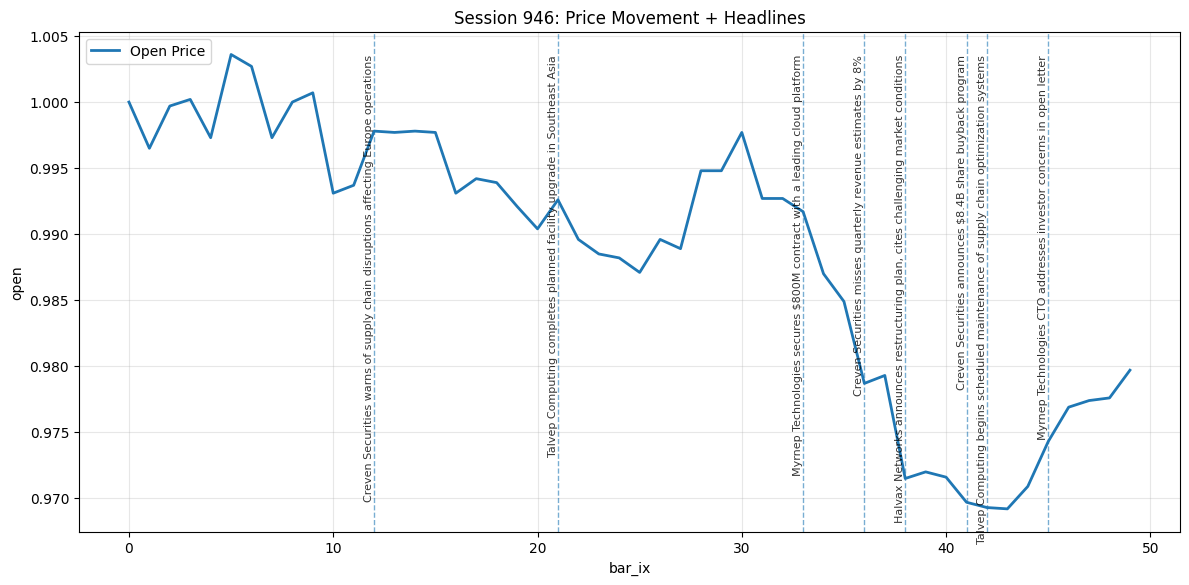

In [565]:
#Session 946
for s in headlines_seen_train[headlines_seen_train['session'] == 946]['headline']: 
    print(s)
plot_session_with_news(
    bars_seen_train,
    headlines_seen_train,
    session_n=946,
    price_col="open",
    figsize=(12, 6),
    show_headlines=True,
)

In [566]:
company_predictions = pd.read_csv("session_company_assignments.csv")
company_predictions.head(10)

,session,predicted_company,ensemble_score,n_headlines,score_margin
0,0,Orevex Renewables,0.651226,3,0.330127
1,1,Halvav Brands,0.451345,2,0.155610
2,2,Kelvik Power,0.141421,6,0.282843
3,3,Talvix Holdings,0.512489,4,0.663941
4,4,Zelval Energy,0.724330,2,0.716691
5,5,Nolvol Resources,0.753623,4,0.501258
6,6,Nolvav Commerce,0.410671,3,0.249006
7,7,Myrnep Technologies,0.513803,5,0.004517
8,8,Ilval Financial,0.819256,4,1.116577
9,9,Halvax Networks,0.684960,1,0.447056


In [567]:
sum(company_predictions['score_margin'] > 1.0)

146

In [568]:
spotlight_words_check = [
    'breakthrough', 'merger', 'expands', 'improvement', 'acquisition',
    'withdraws', 'competitor', 'loses', 'warns', 'concerns',
    'robust', 'increase', 'decline', 'record', 'partnership'
]

positive_words = ['breakthrough', 'expands', 'improvement', 'acquisition', 'robust', 'increase', 'record', 'partnership']
negative_words = ['merger', 'withdraws', 'competitor', 'loses', 'warns', 'concerns', 'decline']

trade_decision = pd.DataFrame({
    "session": company_predictions['session'],
    "target_position": 1,
})

for session in company_predictions['session']:
    company = company_predictions[company_predictions['session'] == session]['predicted_company'].item()
    if float(company_predictions[company_predictions['session'] == session]['score_margin'].item()) < 1: 
        continue
    session_headlines = headlines_seen_train[headlines_seen_train['session'] == session]
    for headline in session_headlines['headline']:
        if company in headline: 
            if any(word in headline for word in positive_words):
                trade_decision.loc[trade_decision['session'] == session, 'target_position'] += 0.5
            elif any(word in headline for word in negative_words):
                trade_decision.loc[trade_decision['session'] == session, 'target_position'] += -0.5

backtest(trade_decision)

  Sessions evaluated : 1000
  Sharpe ratio       : +2.6896
  Mean PnL           : +0.003503
  Std  PnL           : 0.020840
  Win rate           : 56.40%


/var/folders/1r/8kyrcg852fgf6nffdk5rw72w0000gn/T/ipykernel_49209/2491221457.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  trade_decision.loc[trade_decision['session'] == session, 'target_position'] += 0.5


,session,volume,close_halfway,close_end,ret,pnl
0,0,1.0,1.0316,1.0528,0.020551,0.020551
1,1,1.0,1.0286,0.9774,-0.049776,-0.049776
2,2,1.0,1.0208,1.0488,0.027429,0.027429
3,3,1.0,1.0113,0.9948,-0.016316,-0.016316
4,4,1.0,1.0280,1.0338,0.005642,0.005642
...,...,...,...,...,...,...
995,995,1.0,0.9913,0.9812,-0.010189,-0.010189
996,996,1.0,0.9915,1.0661,0.075240,0.075240
997,997,1.0,0.9796,1.0028,0.023683,0.023683
998,998,1.0,1.0142,1.0028,-0.011240,-0.011240


In [569]:
company_predictions = pd.read_csv("session_company_classifications_all.csv")
company_predictions.head(10)
#drop first 1000 rows
company_predictions = company_predictions[company_predictions['session'] >= 1000]
company_predictions.head(10)

,session,predicted_company,ensemble_score,n_headlines,score_margin,split
1000,1000,Yorval Partners,0.409941,3,0.025270,public_test
1001,1001,Jorvis Fuels,0.733651,4,0.188935,public_test
1002,1002,Plevik Energy,0.561066,2,0.710894,public_test
1003,1003,Plevep Power,1.199665,5,0.915099,public_test
1004,1004,Talvix Holdings,1.039982,5,0.780744,public_test
1005,1005,Relvos Biosciences,1.136674,3,1.127049,public_test
1006,1006,Krevan Investments,0.860172,6,0.638974,public_test
1007,1007,Joval Brands,1.024188,2,1.356710,public_test
1008,1008,Zelvon Biosciences,0.640784,6,0.646143,public_test
1009,1009,Wyrnik Sciences,0.414860,1,0.693940,public_test


In [570]:
all_headlines = pd.concat([headlines_seen_public_test, headlines_seen_private_test], ignore_index=False)
all_headlines

,session,headline,bar_ix
17371,1000,Yorval Partners completes planned facility upg...,6
17372,1000,Yorval Partners secures $500M contract with a ...,12
17373,1000,Yorval Partners completes planned facility upg...,15
17374,1000,Ilval Financial explores strategic alternative...,24
17375,1000,Kelvos Resources secures $120M contract with a...,31
...,...,...,...
366727,20999,Zrovum Biopharma opens new office in Asia Pacific,9
366728,20999,Ixenix Technologies delays product launch in e...,18
366729,20999,Jorvix Diagnostics to present at Tech Leadersh...,22
366730,20999,Ixenix Technologies faces class action over pr...,28


In [571]:
spotlight_words_check = [
    'breakthrough', 'merger', 'expands', 'improvement', 'acquisition',
    'withdraws', 'competitor', 'loses', 'warns', 'concerns',
    'robust', 'increase', 'decline', 'record', 'partnership'
]

positive_words = ['breakthrough', 'expands', 'improvement', 'acquisition', 'robust', 'increase', 'record', 'partnership']
negative_words = ['merger', 'withdraws', 'competitor', 'loses', 'warns', 'concerns', 'decline']

trade_decision = pd.DataFrame({
    "session": company_predictions['session'],
    "target_position": 1,
})

all_headlines = pd.concat([headlines_seen_public_test, headlines_seen_private_test], ignore_index=False)


for session in company_predictions['session']:
    company = company_predictions[company_predictions['session'] == session]['predicted_company'].item()
    if float(company_predictions[company_predictions['session'] == session]['score_margin'].item()) < 1: 
        continue
    session_headlines = all_headlines[all_headlines['session'] == session]
    for headline in session_headlines['headline']:
        if company in headline: 
            if any(word in headline for word in positive_words):
                trade_decision.loc[trade_decision['session'] == session, 'target_position'] += 0.5
            elif any(word in headline for word in negative_words):
                trade_decision.loc[trade_decision['session'] == session, 'target_position'] += -0.5

backtest(trade_decision)

/var/folders/1r/8kyrcg852fgf6nffdk5rw72w0000gn/T/ipykernel_49209/3813059540.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  trade_decision.loc[trade_decision['session'] == session, 'target_position'] += 0.5


[backtester] Warning: 19999 session(s) not found in train data.
  Sessions evaluated : 0
  Sharpe ratio       : +nan
  Mean PnL           : +nan
  Std  PnL           : nan
  Win rate           : nan%


,session,volume,close_halfway,close_end,ret,pnl


In [572]:
all_sessions = set() 
for session in company_predictions['session']:
    all_sessions.add(session)
    

add_val = 0
for i in range(1000, 21000):
    if i not in all_sessions:
        add_val = i
        

no_headline_sesh = {
    "session": add_val,
    "target_position": 0
}
trade_decision = pd.concat([trade_decision, pd.DataFrame([no_headline_sesh])], ignore_index=True)
trade_decision

,session,target_position
0,1000,1.0
1,1001,1.0
2,1002,1.0
3,1003,1.0
4,1004,1.0
...,...,...
19995,20996,1.0
19996,20997,1.0
19997,20998,1.0
19998,20999,1.0


In [573]:
keywords = [
    "completes planned facility upgrade",
    "warns of supply chain disruptions affecting",
    "wins industry award",
    "announces significant capital expenditure plan for",
    "withdraws from",
    "recalls products in",
    "reports rising costs pressuring margins",
    "completes strategic acquisition",
    "increase in customer acquisition",
    "loses key contract",
    "reports record quarterly",
    "names new",
    "decline in operating income",
    "secures",
    "expands operations into",
    "launches next-generation",
    "begins scheduled maintenance",
    "margin improvement",
    "drop in new customer orders this quarter",
    "reports strong demand in",
    "files routine",
    "files for regulatory",
    "explores strategic alternatives",
    "confirms participation",
    "delays product launch",
    "opens new office",
    "enters joint venture",
    "faces class action",
    "sees mixed results in",
    "board meeting",
    "misses quarterly revenue estimates",
    "faces regulatory review",
    "to host investor day focused on",
    "announces breakthrough in",
    "revises long-term strategy with focus on",
    "share buyback program",
    "signs multi-year partnership with a",
    "to present at",
    "announces restructuring plan",
    "reports unexpected decline in",
    "announces major organizational restructuring",
    "publishes annual sustainability report",
    "lowers full-year guidance amid softening demand",
    "addresses investor concerns in open letter",
    "steps down unexpectedly",
    "raises full-year guidance citing robust demand",
    "in talks for potential merger, details undisclosed",
    "achieves key regulatory milestone ahead of schedule",
    "beats analyst expectations with strong earnings growth",
    "schedules annual shareholder meeting for next month"
]

## Strategy B: Keyword Lookup → Test Submission

1. **Train** a lookup table `keyword → mean 2nd-half return` using owner-matched headlines from the training data.
2. For each test session, find the **last headline from the predicted session owner** in bars 0–49.
3. Extract its keyword, look up the expected direction, set `target_position = sign(mean_ret)`.
4. Sessions with no owner headline or a neutral keyword get `target_position = 0`.

In [574]:
# ── Step 1: build the keyword → return lookup from training data ──────────────

def extract_keyword(headline, kw_list):
    hl = headline.lower()
    for kw in kw_list:
        if kw in hl:
            return kw
    return None

# Company labels for training sessions
train_classifications = pd.read_csv('session_company_classifications_train.csv')[['session','predicted_company']]

# Add keyword + company to seen training headlines
hl_train = headlines_seen_train.copy()
hl_train['keyword'] = hl_train['headline'].apply(lambda h: extract_keyword(h, keywords))
hl_train['company'] = hl_train['headline'].str.split().str[:2].str.join(' ')

# Add keyword + company to unseen training headlines
hl_unseen = headlines_unseen_train.copy()
hl_unseen['keyword'] = hl_unseen['headline'].apply(lambda h: extract_keyword(h, keywords))
hl_unseen['company'] = hl_unseen['headline'].str.split().str[:2].str.join(' ')

# Filter to owner-matched headlines only
hl_train_owner  = hl_train.merge(train_classifications, on='session').query('company == predicted_company')
hl_unseen_owner = hl_unseen.merge(train_classifications, on='session').query('company == predicted_company')

# Last keyword seen per training session
last_kw_train = (
    hl_train_owner.sort_values('bar_ix')
    .groupby('session').last()
    .reset_index()[['session','keyword']]
    .rename(columns={'keyword': 'kw_last'})
)

# 2nd-half return per training session
halfway_close = bars_seen_train[bars_seen_train['bar_ix'] == 49].set_index('session')['close']
end_close     = bars_unseen_train[bars_unseen_train['bar_ix'] == 99].set_index('session')['close']
train_ret = (end_close / halfway_close - 1).rename('ret').reset_index()

# Keyword → mean return lookup
kw_lookup = (
    last_kw_train.merge(train_ret, on='session')
    .groupby('kw_last')['ret']
    .agg(mean_ret='mean', count='count')
    .sort_values('mean_ret', ascending=False)
)
print(f'Keyword lookup table: {len(kw_lookup)} keywords')
print(kw_lookup.to_string())


Keyword lookup table: 50 keywords
                                                        mean_ret  count
kw_last                                                                
raises full-year guidance citing robust demand          0.020382      2
signs multi-year partnership with a                     0.018834     15
board meeting                                           0.014837      1
announces major organizational restructuring            0.013311      4
announces breakthrough in                               0.012643     19
recalls products in                                     0.011483     29
withdraws from                                          0.010597     20
steps down unexpectedly                                 0.010478      8
increase in customer acquisition                        0.010170     22
opens new office                                        0.006601     13
announces restructuring plan                            0.006247      2
completes strategic acquisitio

In [575]:
# ── Step 2: apply to public and private test sessions ─────────────────────────

def make_predictions(bars_seen, headlines_seen, classifications_csv):
    classifications = pd.read_csv(classifications_csv)[['session','predicted_company']]

    hl = headlines_seen.copy()
    hl['keyword'] = hl['headline'].apply(lambda h: extract_keyword(h, keywords))
    hl['company'] = hl['headline'].str.split().str[:2].str.join(' ')

    # Last owner-matched keyword per session
    hl_owner = hl.merge(classifications, on='session').query('company == predicted_company')
    last_kw = (
        hl_owner.sort_values('bar_ix')
        .groupby('session').last()
        .reset_index()[['session','keyword']]
        .rename(columns={'keyword': 'kw_last'})
    )

    # All sessions in this split
    all_sessions = pd.DataFrame({'session': bars_seen['session'].unique()})

    preds = (
        all_sessions
        .merge(last_kw, on='session', how='left')
        .merge(kw_lookup[['mean_ret']].reset_index(), on='kw_last', how='left')
        .fillna({'mean_ret': 0})
    )
    preds['target_position'] = np.sign(preds['mean_ret'])
    return preds[['session','target_position','kw_last','mean_ret']].sort_values('session')

pred_public  = make_predictions(bars_seen_public_test,  headlines_seen_public_test,
                                'session_company_classifications_public.csv')
pred_private = make_predictions(bars_seen_private_test, headlines_seen_private_test,
                                'session_company_classifications_private.csv')

print('Public test positions:')
print(pred_public['target_position'].value_counts().sort_index())
print(f'  No-signal sessions (pos=0): {(pred_public["target_position"]==0).sum()}')
print()
print('Private test positions:')
print(pred_private['target_position'].value_counts().sort_index())
print(f'  No-signal sessions (pos=0): {(pred_private["target_position"]==0).sum()}')

# pred = make_predictions(bars_seen_train, headlines_seen_train, 'session_company_assignments.csv')
# print('Train positions:')
# print(pred['target_position'].value_counts().sort_index())
# print(f'  No-signal sessions (pos=0): {(pred["target_position"]==0).sum()}')    
# backtest(pred[['session','target_position']])



Public test positions:
target_position
-1.0    1721
 1.0    8279
Name: count, dtype: int64
  No-signal sessions (pos=0): 0

Private test positions:
target_position
-1.0    1634
 0.0       1
 1.0    8365
Name: count, dtype: int64
  No-signal sessions (pos=0): 1


In [576]:
combined = pd.concat([pred_public, pred_private], ignore_index=True)
combined[["session", "target_position"]].to_csv("trade_decision_keywords.csv", index=False)

---
## Strategy D: Kelly-Scaled Position Sizing

Rather than binary `sign(mean_ret)`, scale position by the **Kelly criterion**: `position ∝ μ / σ²`

- High mean + low variance → large position
- Low mean or high variance → small position
- Positions are clipped at the 75th percentile of |Kelly| to protect against outliers from low-count keywords.

In [589]:
# Build full keyword stats with variance from training data
kw_stats_full = (
    last_kw_train.merge(train_ret, on='session')
    .groupby('kw_last')['ret']
    .agg(mean_ret='mean', count='count', std_ret='std')
    .assign(
        variance  = lambda d: d['std_ret'] ** 2,
        kelly     = lambda d: d['mean_ret'] / (d['variance'] + 1e-9),
    )
    .reset_index()
)

# Clip at 75th percentile of |kelly| across non-zero keywords
nonzero = kw_stats_full.loc[kw_stats_full['kelly'] != 0, 'kelly'].abs()
clip_val = nonzero.quantile(0.75)
kw_stats_full['kelly_clipped'] = kw_stats_full['kelly'].clip(-clip_val, clip_val)

print(f'Clip value (75th pct of |Kelly|): {clip_val:.2f}')
print()
print('Keyword Kelly table (sorted by Kelly strength):')
print(kw_stats_full.sort_values('kelly', ascending=False)
      [['kw_last','mean_ret','std_ret','kelly','kelly_clipped','count']].to_string(index=False))


Clip value (75th pct of |Kelly|): 18.49

Keyword Kelly table (sorted by Kelly strength):
                                               kw_last  mean_ret  std_ret       kelly  kelly_clipped  count
        raises full-year guidance citing robust demand  0.020382 0.012238  136.082764      18.494743      2
                   signs multi-year partnership with a  0.018834 0.012439  121.728742      18.494743     15
          announces major organizational restructuring  0.013311 0.015796   53.344838      18.494743      4
                                      opens new office  0.006601 0.012261   43.908880      18.494743     13
                      increase in customer acquisition  0.010170 0.015500   42.332523      18.494743     22
                                   recalls products in  0.011483 0.017528   37.377372      18.494743     29
                                        withdraws from  0.010597 0.017593   34.238145      18.494743     20
                             announces breakthr

In [585]:
# Penalise Kelly position when sample count is low
# penalty = min(1, count / 5)  →  count=1: 0.20×, count=2: 0.40×, count=5+: 1.00×
MIN_COUNT = 5
kw_stats_full['count_penalty'] = (kw_stats_full['count'] / MIN_COUNT).clip(upper=1.0)
kw_stats_full['kelly_clipped']  = kw_stats_full['kelly'].clip(-clip_val, clip_val) * kw_stats_full['count_penalty']

print('Keyword table with count penalty applied:')
print(
    kw_stats_full.sort_values('kelly', ascending=False)
    [['kw_last','mean_ret','count','count_penalty','kelly','kelly_clipped']]
    .to_string(index=False)
)


Keyword table with count penalty applied:
                                               kw_last  mean_ret  count  count_penalty       kelly  kelly_clipped
        raises full-year guidance citing robust demand  0.020382      2            0.4  136.082764      11.334958
                   signs multi-year partnership with a  0.018834     15            1.0  121.728742      28.337396
          announces major organizational restructuring  0.013311      4            0.8   53.344838      22.669917
                                      opens new office  0.006601     13            1.0   43.908880      28.337396
                      increase in customer acquisition  0.010170     22            1.0   42.332523      28.337396
                                   recalls products in  0.011483     29            1.0   37.377372      28.337396
                                        withdraws from  0.010597     20            1.0   34.238145      28.337396
                             announces breakth

In [586]:
def make_kelly_predictions(bars_seen, headlines_seen, classifications_csv):
    classifications = pd.read_csv(classifications_csv)[['session','predicted_company']]

    hl = headlines_seen.copy()
    hl['keyword'] = hl['headline'].apply(lambda h: extract_keyword(h, keywords))
    hl['company'] = hl['headline'].str.split().str[:2].str.join(' ')

    hl_owner = hl.merge(classifications, on='session').query('company == predicted_company')
    last_kw = (
        hl_owner.sort_values('bar_ix').groupby('session').last()
        .reset_index()[['session','keyword']].rename(columns={'keyword': 'kw_last'})
    )

    all_sessions = pd.DataFrame({'session': bars_seen['session'].unique()})
    preds = (
        all_sessions
        .merge(last_kw, on='session', how='left')
        .merge(kw_stats_full[['kw_last','kelly_clipped']], on='kw_last', how='left')
        .fillna({'kelly_clipped': 0})
    )
    preds['target_position'] = preds['kelly_clipped']
    return preds[['session','target_position','kw_last']].sort_values('session')

kelly_public  = make_kelly_predictions(bars_seen_public_test,  headlines_seen_public_test,
                                        'session_company_classifications_public.csv')
kelly_private = make_kelly_predictions(bars_seen_private_test, headlines_seen_private_test,
                                        'session_company_classifications_private.csv')

print('Public Kelly positions:')
print(kelly_public['target_position'].describe())
print(f'  Flat (pos=0): {(kelly_public["target_position"]==0).sum()}')
print()
print('Private Kelly positions:')
print(kelly_private['target_position'].describe())
print(f'  Flat (pos=0): {(kelly_private["target_position"]==0).sum()}')


Public Kelly positions:
count    10000.000000
mean         8.584762
std         10.450350
min        -28.337396
25%          1.008285
50%          7.773713
75%         13.861187
max         28.337396
Name: target_position, dtype: float64
  Flat (pos=0): 90

Private Kelly positions:
count    10000.000000
mean         8.794027
std         10.380527
min        -28.337396
25%          1.008285
50%          7.773713
75%         13.861187
max         28.337396
Name: target_position, dtype: float64
  Flat (pos=0): 94


In [587]:
kelly_public[['session','target_position']].to_csv('submission_public_kelly.csv',  index=False)
kelly_private[['session','target_position']].to_csv('submission_private_kelly.csv', index=False)

print('Saved submission_public_kelly.csv  :', len(kelly_public),  'rows')
print('Saved submission_private_kelly.csv :', len(kelly_private), 'rows')
print()
print('Public preview:')
print(kelly_public.head(10).to_string(index=False))
print()
print('Private preview:')
print(kelly_private.head(10).to_string(index=False))


Saved submission_public_kelly.csv  : 10000 rows
Saved submission_private_kelly.csv : 10000 rows

Public preview:
 session  target_position                                  kw_last
    1000        -0.771323       completes planned facility upgrade
    1001         3.329353 drop in new customer orders this quarter
    1002        13.861187                                  secures
    1003         1.794984                    sees mixed results in
    1004        13.861187                                  secures
    1005         3.740979                     enters joint venture
    1006        28.337396                announces breakthrough in
    1007        12.210778                     files for regulatory
    1008        28.337396         increase in customer acquisition
    1009        -1.038291                      wins industry award

Private preview:
 session  target_position                                            kw_last
   11000         9.117117                    completes 

In [588]:
total_kelly = pd.concat([kelly_public, kelly_private], ignore_index=True)
total_kelly[['session','target_position']].to_csv('submission_total_kelly.csv', index=False)

In [582]:
# Re-run predictions with penalised Kelly and overwrite submission files
kelly_public  = make_kelly_predictions(bars_seen_public_test,  headlines_seen_public_test,
                                        'session_company_classifications_public.csv')
kelly_private = make_kelly_predictions(bars_seen_private_test, headlines_seen_private_test,
                                        'session_company_classifications_private.csv')

kelly_public[['session','target_position']].to_csv('submission_public_kelly.csv',  index=False)
kelly_private[['session','target_position']].to_csv('submission_private_kelly.csv', index=False)

print('Public  (penalised Kelly):', len(kelly_public),  'rows')
print('  range:', kelly_public['target_position'].min().round(2), 'to', kelly_public['target_position'].max().round(2))
print('  flat (pos=0):', (kelly_public['target_position']==0).sum())
print()
print('Private (penalised Kelly):', len(kelly_private), 'rows')
print('  range:', kelly_private['target_position'].min().round(2), 'to', kelly_private['target_position'].max().round(2))
print('  flat (pos=0):', (kelly_private['target_position']==0).sum())
print()
print('Saved submission_public_kelly.csv + submission_private_kelly.csv')


Public  (penalised Kelly): 10000 rows
  range: -18.49 to 18.49
  flat (pos=0): 90

Private (penalised Kelly): 10000 rows
  range: -18.49 to 18.49
  flat (pos=0): 94

Saved submission_public_kelly.csv + submission_private_kelly.csv
